# Fitting a Signal/Background classification model on MG5 data

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 120

## Data loading

In [3]:
from diquark.data.loader import DataLoader

path_dict = {
    "BKG:NoJets": "/data/gmajeri/diquark-simulations/background/ATLAS_data_136_ttbar_100k_htmin_MSuu_8TeV/Events/run_ttbar/tag_1_delphes_events.root",
    "BKG:1Jet": "/data/gmajeri/diquark-simulations/background/ATLAS_data_136_ttbar_1jet_100k_htmin_MSuu_8TeV/Events/run_ttbar/tag_1_delphes_events.root",
    "SIG:Suu": "/data/iduminic/diquark-analysis/full-hadro/sgn/chi-chi/wb-ht/jjb-bbt/m_chi-2000/136_8000_events.root"
}

data_loader = DataLoader(
    path_dict,
    # index_start=0,
    # index_stop=50_000,
)

In [4]:
data = data_loader.load_data()
data

Loading data:   0%|          | 0/3 [00:00<?, ?it/s]

{'BKG:NoJets': <Array [{Jet: 2, 'Jet/Jet.PT': ..., ...}, ...] type='12584 * {Jet: int32, "...'>,
 'BKG:1Jet': <Array [{Jet: 5, 'Jet/Jet.PT': ..., ...}, ...] type='4399 * {Jet: int32, "J...'>,
 'SIG:Suu': <Array [{Jet: 8, 'Jet/Jet.PT': ..., ...}, ...] type='100000 * {Jet: int32, ...'>}

In [6]:
from diquark.features.feature_extractor import FeatureExtractor

feature_extractor = FeatureExtractor(32, 2000, 8000)
features = { key: feature_extractor.compute_all(subset) for key, subset in data.items() }
features

{'BKG:NoJets': {'jet_multiplicity': array([2, 2, 2, ..., 3, 3, 3], shape=(12584,), dtype=int32),
  'p_T_min': array([1427.4363  ,  965.76337 ,  995.58875 , ...,   31.70635 ,
           26.283772,   25.308317], shape=(12584,), dtype=float32),
  'p_T_mean': array([1429.87695312, 1087.87243652, 1033.85742188, ...,  440.05354818,
         1187.58072917,  845.56420898], shape=(12584,)),
  'p_T_stddev': array([  2.42876964, 122.10881153,  38.26821441, ..., 317.87880904,
         821.51649104, 580.22452707], shape=(12584,)),
  'p_T_max': array([1432.3176, 1209.9814, 1072.1261, ...,  807.0455, 1797.8234,
         1275.0796], shape=(12584,), dtype=float32),
  'eta_min': array([ 0.3121892 , -1.0230983 ,  0.9758854 , ..., -2.9334674 ,
         -0.18355645, -0.3335036 ], shape=(12584,), dtype=float32),
  'eta_mean': array([ 0.52321255, -0.7003684 ,  1.26317024, ..., -1.54026794,
          0.96222417,  0.13883446], shape=(12584,)),
  'eta_stddev': array([0.21102325, 0.32272997, 0.28728453, ..., 1.0

In [10]:
import pandas as pd

dataframes = []

for key, features_dict in features.items():
    df = pd.DataFrame(features_dict)
    df['label'] = key
    dataframes.append(df)

df = pd.concat(dataframes)
df.sample(20)

,jet_multiplicity,p_T_min,p_T_mean,p_T_stddev,p_T_max,eta_min,eta_mean,eta_stddev,eta_max,phi_min,...,chi2_first_component_max,chi2_second_component_min,chi2_second_component_mean,chi2_second_component_stddev,chi2_second_component_max,chi2_third_component_min,chi2_third_component_mean,chi2_third_component_stddev,chi2_third_component_max,label
50520,9,24.882200,687.402289,761.920514,2085.637207,-0.576127,0.192456,0.586422,1.127428,-1.838144,...,53938.746094,0.314843,1410.696987,1787.399258,11071.303711,26.593307,1469.029669,1264.072716,4933.647461,SIG:Suu
3728,3,532.652588,1396.830404,653.889509,2113.972412,-0.597564,-0.053408,0.384777,0.219437,-1.249878,...,36672.757812,3916.309082,3916.309082,0.417133,3916.309082,0.000000,0.000000,0.000000,0.000000,BKG:1Jet
70147,5,24.981861,707.260840,427.161333,1142.699463,-1.501999,0.039183,1.282622,2.115309,-1.618902,...,33962.789062,8.244512,2436.043750,2330.568954,6439.537109,0.000000,0.000000,0.000000,0.000000,SIG:Suu
80213,7,25.736351,506.282401,552.927328,1404.927734,-1.989713,-0.179571,1.565962,2.714214,-3.082341,...,100448.781250,0.009994,2465.949107,4680.212953,14391.045898,12.139849,683.074358,1115.769558,3049.303223,SIG:Suu
43288,4,184.447128,1718.591309,1250.154756,3462.412109,-0.630686,0.031561,0.616818,1.027997,-2.819123,...,74129.531250,21.873892,6671.694824,5680.350709,14498.374023,0.000000,0.000000,0.000000,0.000000,SIG:Suu
27691,6,27.322708,1174.966471,1063.489833,2799.748779,-3.190877,-0.682595,1.185709,0.425135,-1.213327,...,65657.179688,0.047358,2580.169531,3815.894599,13791.942383,1.526830,1.526830,0.000278,1.526830,SIG:Suu
86679,5,37.883686,1319.127539,1033.601343,2688.990967,-0.864322,-0.183897,0.566882,0.543327,-2.135972,...,77643.281250,0.002616,3744.248047,5040.285881,13974.273438,0.000000,0.000000,0.000000,0.000000,SIG:Suu
43509,9,36.715900,777.878635,1243.900204,3460.495117,-3.179765,-0.396791,1.140611,0.679564,-1.123895,...,100387.468750,0.084153,1849.308966,3590.538886,15347.474609,7.954136,1733.194382,1553.043063,4966.669434,SIG:Suu
33445,5,34.766731,896.537305,1331.837851,3514.565186,-0.318092,0.518521,0.703380,1.620934,-1.767659,...,22988.289062,128.014771,895.311523,529.836084,1951.869019,0.000000,0.000000,0.000000,0.000000,SIG:Suu
36036,7,40.276505,1033.398786,1100.562041,3104.722412,-0.367395,0.237095,0.426771,0.866671,-2.666736,...,63890.191406,9.397120,1776.918304,2850.161053,12741.041016,36.635006,565.477190,744.687214,2151.893311,SIG:Suu


In [11]:
X = df.drop(labels=['label'], axis='columns')
y = df['label']

assert len(X) == len(y)

In [12]:
y.value_counts()

label
SIG:Suu       100000
BKG:NoJets     12584
BKG:1Jet        4399
Name: count, dtype: int64

## Data preprocessing

In [13]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(X)

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.7, random_state=2, stratify=y)

In [15]:
y_train_target = y_train == 'SIG:Suu'
y_test_target = y_test == 'SIG:Suu'

## Model fitting - XGBoost

In [16]:
import xgboost as xgb

# Use "hist" for constructing the trees, with early stopping enabled.
clf = xgb.XGBClassifier(n_estimators=200, random_state=47, tree_method="hist", early_stopping_rounds=2)

# Fit the model, test sets are used for early stopping.
clf.fit(X_train, y_train_target, eval_set=[(X_test, y_test_target)])

[0]	validation_0-logloss:0.18075
[1]	validation_0-logloss:0.12671
[2]	validation_0-logloss:0.09150
[3]	validation_0-logloss:0.06716
[4]	validation_0-logloss:0.04997
[5]	validation_0-logloss:0.03754
[6]	validation_0-logloss:0.02855
[7]	validation_0-logloss:0.02199
[8]	validation_0-logloss:0.01711
[9]	validation_0-logloss:0.01354
[10]	validation_0-logloss:0.01083
[11]	validation_0-logloss:0.00891
[12]	validation_0-logloss:0.00747
[13]	validation_0-logloss:0.00637
[14]	validation_0-logloss:0.00554
[15]	validation_0-logloss:0.00500
[16]	validation_0-logloss:0.00455
[17]	validation_0-logloss:0.00426
[18]	validation_0-logloss:0.00397
[19]	validation_0-logloss:0.00371
[20]	validation_0-logloss:0.00359
[21]	validation_0-logloss:0.00345
[22]	validation_0-logloss:0.00334
[23]	validation_0-logloss:0.00325
[24]	validation_0-logloss:0.00322
[25]	validation_0-logloss:0.00313
[26]	validation_0-logloss:0.00308
[27]	validation_0-logloss:0.00306
[28]	validation_0-logloss:0.00304
[29]	validation_0-loglos

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,2
,enable_categorical,False
,eval_metric,None


## Model evaluation

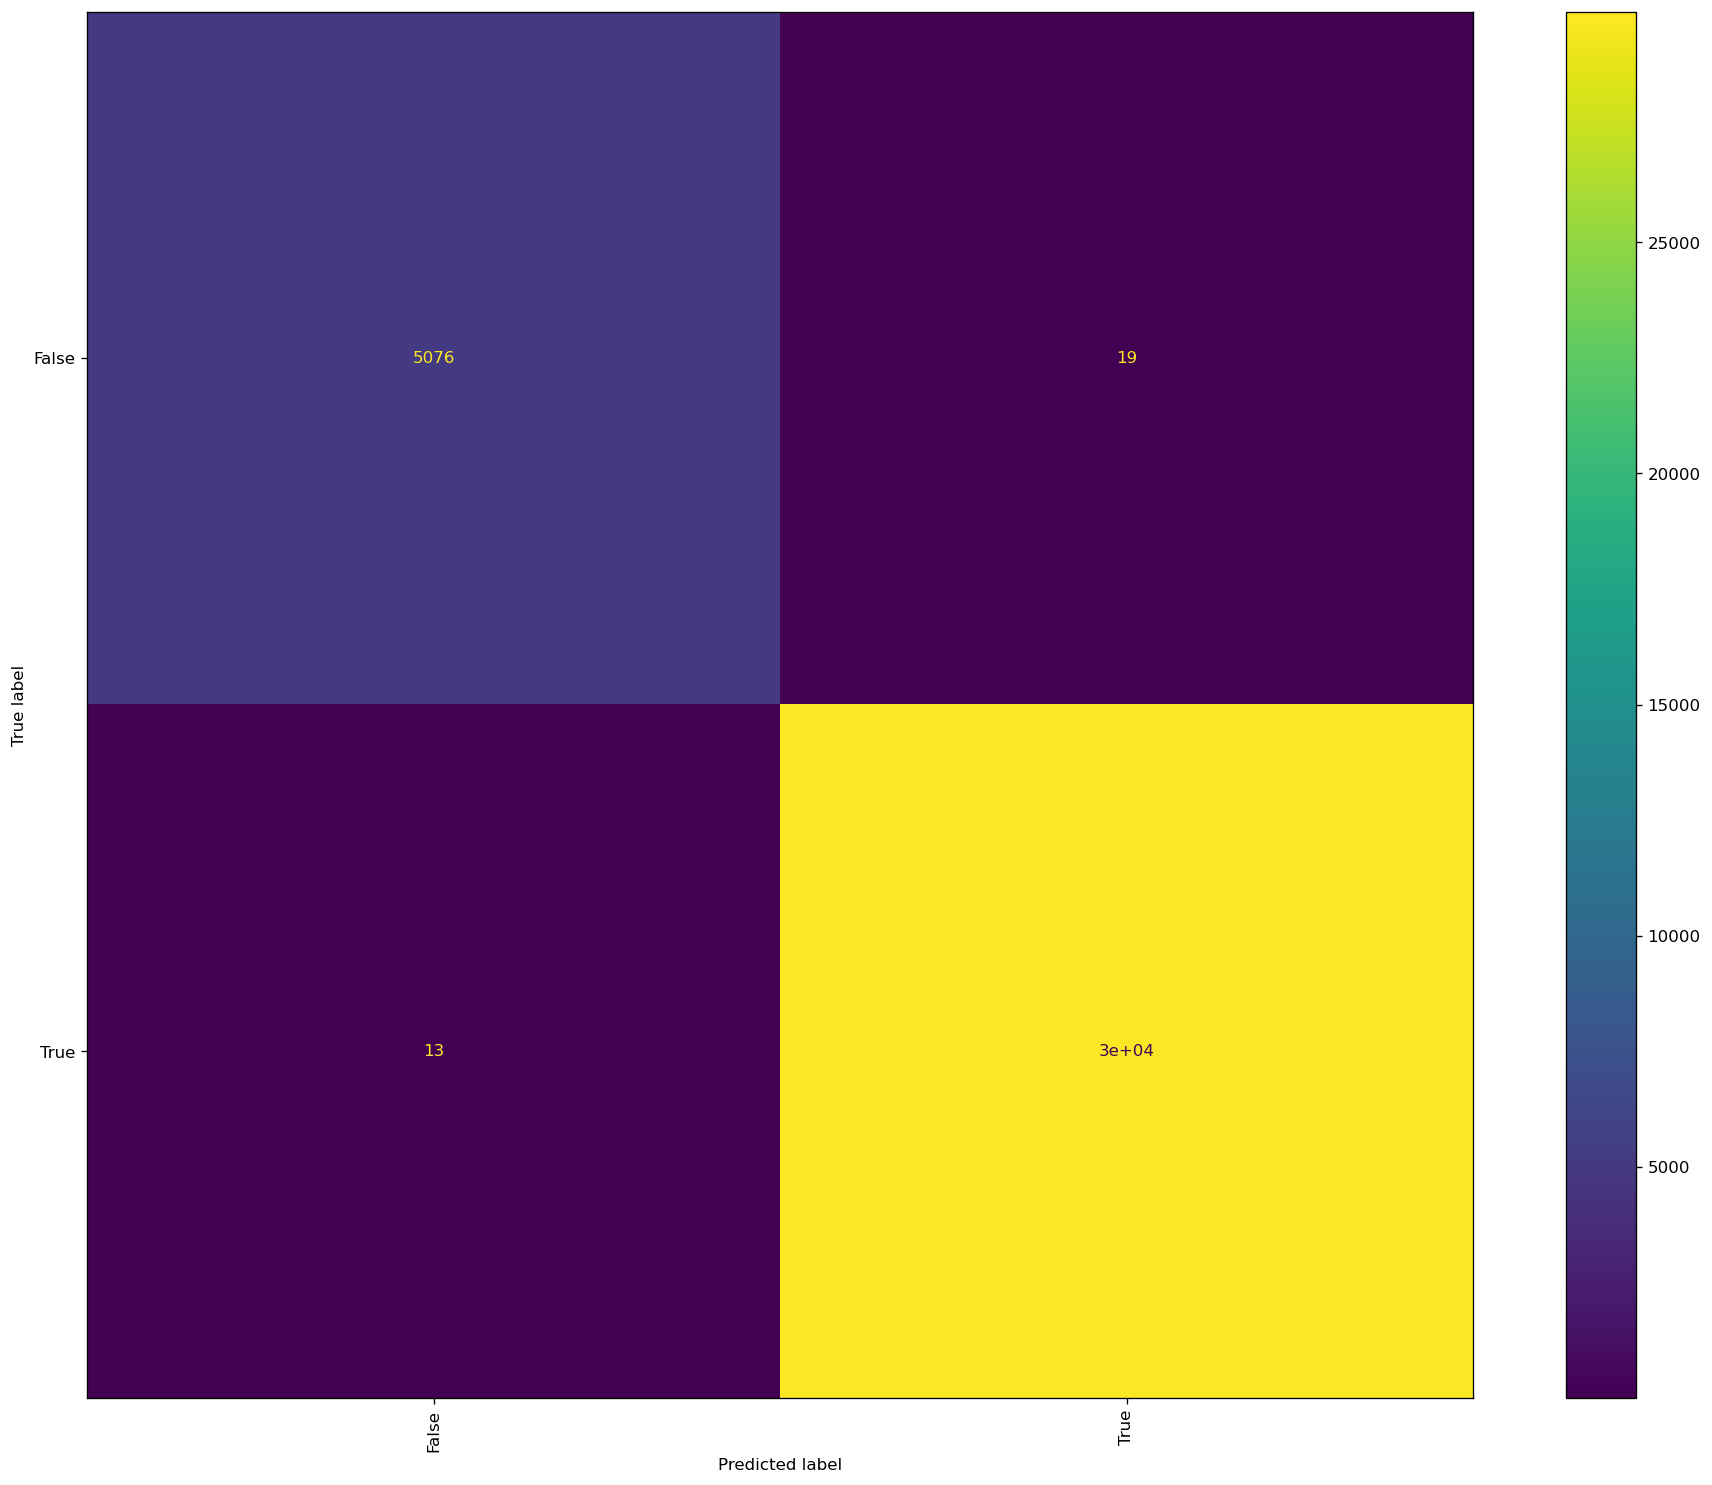

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(20, 15))

cmp = ConfusionMatrixDisplay.from_estimator(clf, X_test, y_test_target, ax=ax)
plt.xticks(rotation=90)
plt.show()

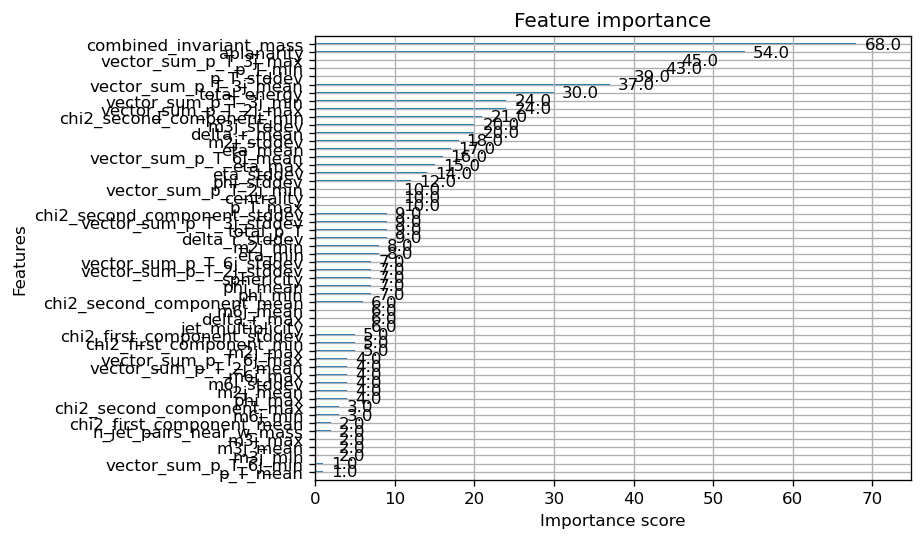

In [18]:
clf.get_booster().feature_names = list(df.columns.drop(['label']).values)
xgb.plot_importance(clf)
plt.show()

In [19]:
y_test_pred = clf.predict_proba(X_test)[:, 1]
y_test_pred

array([0.99998975, 0.9999635 , 0.99998856, ..., 0.9999814 , 0.9999913 ,
       0.9999913 ], shape=(35095,), dtype=float32)

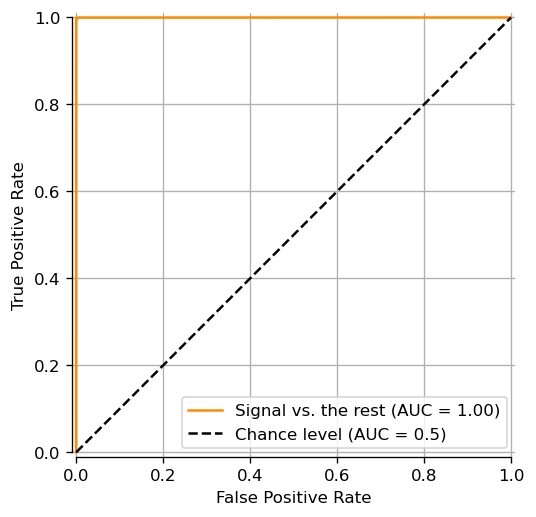

In [20]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    y_test_target,
    y_test_pred,
    name="Signal vs. the rest",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
display.ax_.grid(True)

In [39]:
cross_sections = {
    "SIG:Suu": 1.321E-05,
    # TODO: how much should these be?
    "BKG:NoJets": 3.081,
    "BKG:1Jet": 5.132,
}

In [40]:
sample_weight = np.array([cross_sections[label] for label in y_test])
sample_weight[:5]

array([1.321e-05, 1.321e-05, 1.321e-05, 1.321e-05, 1.321e-05])

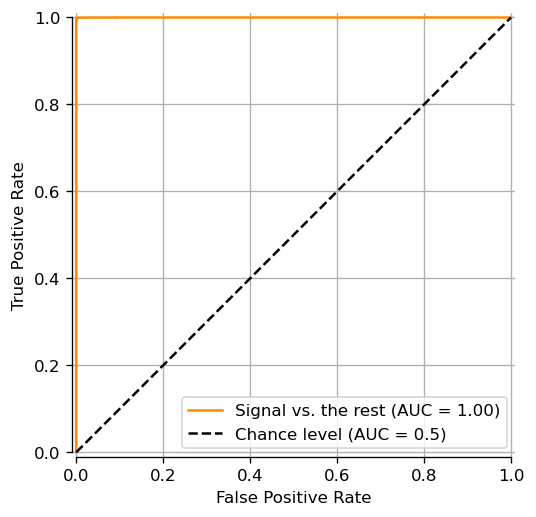

In [41]:
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay.from_predictions(
    y_test_target,
    y_test_pred,
    sample_weight=sample_weight,
    name="Signal vs. the rest",
    curve_kwargs=dict(color="darkorange"),
    plot_chance_level=True,
    despine=True,
)
_ = display.ax_.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
)
display.ax_.grid(True)

In [42]:
from sklearn.metrics import (
    auc,
    precision_recall_curve,
)

precision, recall, thresholds = precision_recall_curve(
    y_test_target,
    y_test_pred,
    sample_weight=sample_weight
)
pr_auc = auc(recall, precision)
print("Precision:", precision)
print("Recall:", recall)
print("Thresholds:", thresholds)
print("AUC:", pr_auc)

Precision: [2.15317112e-05 2.19081794e-05 2.19330805e-05 ... 1.00000000e+00
 1.00000000e+00 1.00000000e+00]
Recall: [1.         1.         1.         ... 0.1893     0.17863333 0.        ]
Thresholds: [2.8213970e-05 2.8493911e-05 2.8512257e-05 ... 9.9999106e-01 9.9999118e-01
 9.9999130e-01]
AUC: 0.9950062023606525


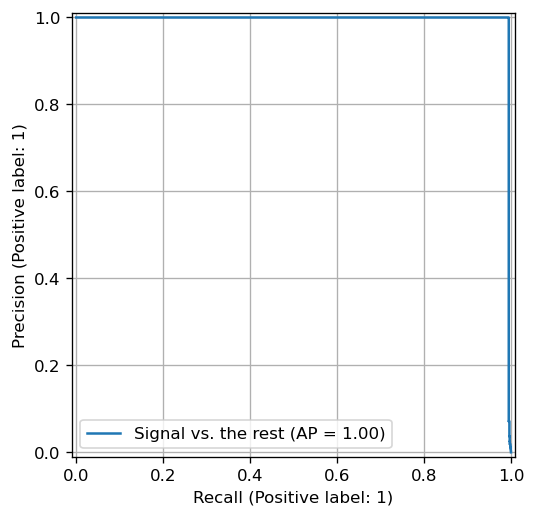

In [43]:
from sklearn.metrics import PrecisionRecallDisplay

display = PrecisionRecallDisplay.from_predictions(
    y_test_target,
    y_test_pred,
    sample_weight=sample_weight,
    name="Signal vs. the rest",
)
display.ax_.grid(True)

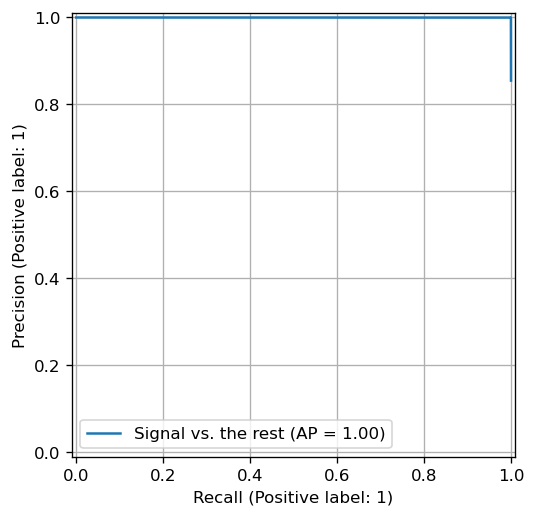

In [44]:
display = PrecisionRecallDisplay.from_predictions(
    y_test_target,
    y_test_pred,
    name="Signal vs. the rest",
)
display.ax_.grid(True)

In [45]:
from diquark.evaluation.metrics import calculate_signal_background_metrics

thresholds = [0.0, 0.5, 0.6, 0.75, 0.85, 0.9, 0.95, 0.96, 0.965, 0.97, 0.98, 0.99]

calculate_signal_background_metrics(
    y_test_target, y_test_pred,
    thresholds, sample_weight,
    total_luminosity=3000, cross_sections=cross_sections,
    use_real_event_percentiles=False,
)

{'signal_efficiency': array([1.        , 0.58413333, 0.4567    , 0.26123333, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 'background_rejection': array([0.01718428, 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        , 1.        , 1.        , 1.        ,
        1.        , 1.        ]),
 'significance': array([0.00294656, 0.4811362 , 0.42542944, 0.32175576, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 's_over_b': array([2.19086594e-05,            inf,            inf,            inf,
                   inf,            inf,            inf,            inf,
                   inf,            inf,            inf,            inf]),
 'thresholds': array([2.82139699e-05, 9.99986529e-01, 9.99988794e-01, 9.99989867e-01,
        9.99991298e-01, 9.99991298e-01, 9.99991298e-01, 9.99991298e-01,
        9.99991298e-01, 9.99991298e-01, 9

## Computing signal/background yields

In [46]:
from diquark.evaluation.metrics import calculate_counts_for_score_cuts

df_counts = calculate_counts_for_score_cuts(
    y_test_target, y_test_pred,
    X_test[:, df.columns.tolist().index('combined_invariant_mass')],
    y_test,
    cross_sections=cross_sections,
    total_luminosity=3000,
    cuts=thresholds,
    use_real_event_percentiles=False
)
df_counts

,Process,0.0,0.5,0.6,0.75,0.85,0.9,0.95,0.96,0.965,0.97,0.98,0.99
0,BKG:1Jet,15244.372727,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,BKG:NoJets,9044.673377,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,SIG:Suu,0.039630,0.023149,0.018099,0.010353,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BKG:sum,24289.046105,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,S/B,0.000002,inf,inf,inf,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
